In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import os
from scipy.stats import gaussian_kde

In [2]:
# --- Section 1: Read and Filter Phenology Data ---
phenology_table = pd.read_csv("alaska_lakes_ice_phenology_2019-2023.csv")

columns_to_keep = [
    "lake_id",
    "centroid_lon",
    "centroid_lat",
    "area_km2",
    "circularity",
    "sdi",
    "convexity",
    "chunk",
    "ice_off_doy",
    "ice_on_doy",
    "ice_free_days",
]
filtered_phenology_table = phenology_table[columns_to_keep]

In [3]:
# --- Section 2: Group by lake_id and Average ---
avg_pheno_table = (
    filtered_phenology_table.groupby("lake_id", as_index=False)
    .mean()
)

# Save the averaged phenology data to a new CSV file
avg_pheno_table.to_csv("averaged_phenology_data.csv", index=False)

In [13]:
# --- Section 3: Read and Process GeoJSON & Supplementary Shapefiles ---
# 1. Process the baseline JSON classification data
bergstedt_jones = gpd.read_file(
    "Integrated_Lake_Ice_Regime_Classification.json"
)

# Parse baseline class characters
class_first_json = bergstedt_jones["Class_IR_b"].str[0]
conditions_json = [class_first_json == "B", class_first_json == "F"]
choices_json = [0, 1]
class_binary_json = np.select(conditions_json, choices_json, default=np.nan)

bergstedt_jones["Class_First"] = class_first_json
bergstedt_jones["Binary"] = class_binary_json

# Filter baseline using 'FID'
bergstedt_jones = bergstedt_jones.rename(columns={"Class_IR_b": "class"})
bergstedt_jones = bergstedt_jones[["FID", "class", "Class_First", "Binary", "geometry"]].copy()

# Print baseline entries
print(f"Initial bergstedt_jones entries: {len(bergstedt_jones)}")

# 2. Process and merge the 6 supplementary shapefiles from the "engram" directory
shapefile_pattern = os.path.join("engram", "*.shp")
shapefile_list = glob.glob(shapefile_pattern)

print(f"\n--- Diagnostic: Searching directory for shapefiles ---")
print(f"Looked for files matching: '{shapefile_pattern}'")
print(f"Found {len(shapefile_list)} shapefile(s): {shapefile_list}\n")

engram_layers = []

for shp_path in shapefile_list:
    try:
        # Read individual shapefile
        gdf = gpd.read_file(shp_path)
        
        # Capture raw original columns immediately
        raw_cols = list(gdf.columns)
        
        print(f"Processing file: {os.path.basename(shp_path)}")
        print(f"  -> RAW COLUMNS FOUND IN FILE: {raw_cols}")
        
        # Convert columns to lowercase internally to handle 'Class' or 'class' seamlessly
        gdf.columns = [col.lower() for col in gdf.columns]
        
        # We only strictly require a classification column now
        if "class" in gdf.columns:
            print("  -> SUCCESS: Found classification column. Adding file layer.")
            # Keep only the classification string and the underlying spatial metadata
            gdf = gdf[["class", "geometry"]].copy()
            engram_layers.append(gdf)
        else:
            print(f"  -> WARNING: Skipped file. Could not find a 'class' column.")
            print(f"     Available lowercase attributes were: {list(gdf.columns)}")
            
    except Exception as e:
        print(f"  -> ERROR: Failed to completely read file {shp_path}. Reason: {e}")

print(f"\n--- Diagnostic Summary ---")
if engram_layers:
    # Row-bind all shapefile data frames vertically 
    engram_combined = gpd.GeoDataFrame(pd.concat(engram_layers, ignore_index=True), crs=engram_layers[0].crs)
    print(f"Total entries from all successfully merged shapefiles (raw): {len(engram_combined)}")
    
    # Filter row entries where the first character of the 'class' column is strictly 'B' or 'F'
    class_first_shp = engram_combined["class"].astype(str).str[0]
    valid_rows_mask = class_first_shp.isin(["B", "F"])
    engram_combined = engram_combined[valid_rows_mask].copy()
    print(f"Merged shapefile entries after B/F character filtering: {len(engram_combined)}")
    
    # Recompute slice metrics for the valid filtered shapefile frame
    class_first_filtered = engram_combined["class"].astype(str).str[0]
    conditions_shp = [class_first_filtered == "B", class_first_filtered == "F"]
    class_binary_shp = np.select(conditions_shp, choices_json, default=np.nan)
    
    engram_combined["Class_First"] = class_first_filtered
    engram_combined["Binary"] = class_binary_shp
    
    # Harmonize the Coordinate Reference System (CRS) with the JSON layer before spatial filtering
    if engram_combined.crs != bergstedt_jones.crs:
        engram_combined = engram_combined.to_crs(bergstedt_jones.crs)
        
    # --- Spatial Overlap Check & Prioritization ---
    # Find which engram shapefile polygons intersect geographically with any bergstedt_jones polygon
    overlapping_indices = gpd.sjoin(
        engram_combined, 
        bergstedt_jones[["geometry"]], 
        how="inner", 
        predicate="intersects"
    ).index
    
    # Drop the shapefile rows that overlapped, preserving bergstedt_jones completely
    engram_non_overlapping = engram_combined.drop(index=overlapping_indices).copy()
    print(f"Shapefile entries dropped due to spatial overlap with bergstedt_jones: {len(overlapping_indices)}")
    print(f"Shapefile entries remaining after removing overlaps: {len(engram_non_overlapping)}")
    
    # --- Auto-Generate New FIDs ---
    engram_non_overlapping["FID"] = [f"engram_{idx}" for idx in range(len(engram_non_overlapping))]
    
    # Re-order columns to perfectly match bergstedt_jones layout
    engram_non_overlapping = engram_non_overlapping[["FID", "class", "Class_First", "Binary", "geometry"]]
    
    # Print the lengths of both layers immediately prior to combining them
    print(f"\n--- Stacking Datasets ---")
    print(f"Current bergstedt_jones entry count: {len(bergstedt_jones)}")
    print(f"Adding non-overlapping shapefile entry count: {len(engram_non_overlapping)}")
    
    # Combine the datasets vertically
    final_classification_layer = gpd.GeoDataFrame(
        pd.concat([bergstedt_jones, engram_non_overlapping], ignore_index=True), 
        crs=bergstedt_jones.crs
    )
else:
    # Fallback to baseline if no valid shapefiles were caught
    print("No valid shapefiles successfully loaded into the processing list. Falling back strictly to bergstedt_jones.")
    final_classification_layer = bergstedt_jones.copy()

print(f"Final combined classification layer entries: {len(final_classification_layer)}\n")

Initial bergstedt_jones entries: 7419

--- Diagnostic: Searching directory for shapefiles ---
Looked for files matching: 'engram\*.shp'
Found 6 shapefile(s): ['engram\\Barrow_lakeIce_regimes_1992_2016.shp', 'engram\\FishCreek_lakeIce_regimes_1992_2015.shp', 'engram\\Inigok_lakeIce_regimes_1992_2016.shp', 'engram\\Kuparuk_lakeIce_regimes_1992_2015.shp', 'engram\\Teshekpuk_LakeIce_regimes_1992_2016.shp', 'engram\\Umiat_lakeIce_regimes_1992_2016.shp']

Processing file: Barrow_lakeIce_regimes_1992_2016.shp
  -> RAW COLUMNS FOUND IN FILE: ['ID', 'Area_sq_km', 'Lake_hgt_m', 'BRW_wacpID', 'Regime1992', 'prctBFI_92', 'PctHiFI_92', 'Regime1993', 'prctBFI_93', 'PctHiFI_93', 'Regime1994', 'prctBFI_94', 'PctHiFI_94', 'Regime1995', 'prctBFI_95', 'PctHiFI_95', 'Regime1996', 'prctBFI_96', 'PctHiFI_96', 'Regime1997', 'prctBFI_97', 'PctHiFI_97', 'Regime1998', 'prctBFI_98', 'PctHiFI_98', 'Regime1999', 'prctBFI_99', 'PctHiFI_99', 'Regime2000', 'prctBFI_00', 'PctHiFI_00', 'Regime2001', 'prctBFI_01', 'PctH

In [19]:
# --- Section 4: Spatial Join ---
# 1. Convert the averaged phenology DataFrame into a GeoDataFrame of points
avg_pheno_gpd = gpd.GeoDataFrame(
    avg_pheno_table,
    geometry=gpd.points_from_xy(
        x=avg_pheno_table["centroid_lon"], 
        y=avg_pheno_table["centroid_lat"]
    ),
    crs="EPSG:4326",
)

# Ensure layers match CRS before executing join
if final_classification_layer.crs != avg_pheno_gpd.crs:
    final_classification_layer = final_classification_layer.to_crs(avg_pheno_gpd.crs)

# 2. Spatially join using the combined classifications dataset
joined_data = gpd.sjoin(avg_pheno_gpd, final_classification_layer, how="inner", predicate="within")

# Print the number of successfully joined lakes
print(f"Number of lakes successfully matched in spatial join: {len(joined_data)}")

Number of lakes successfully matched in spatial join: 6797


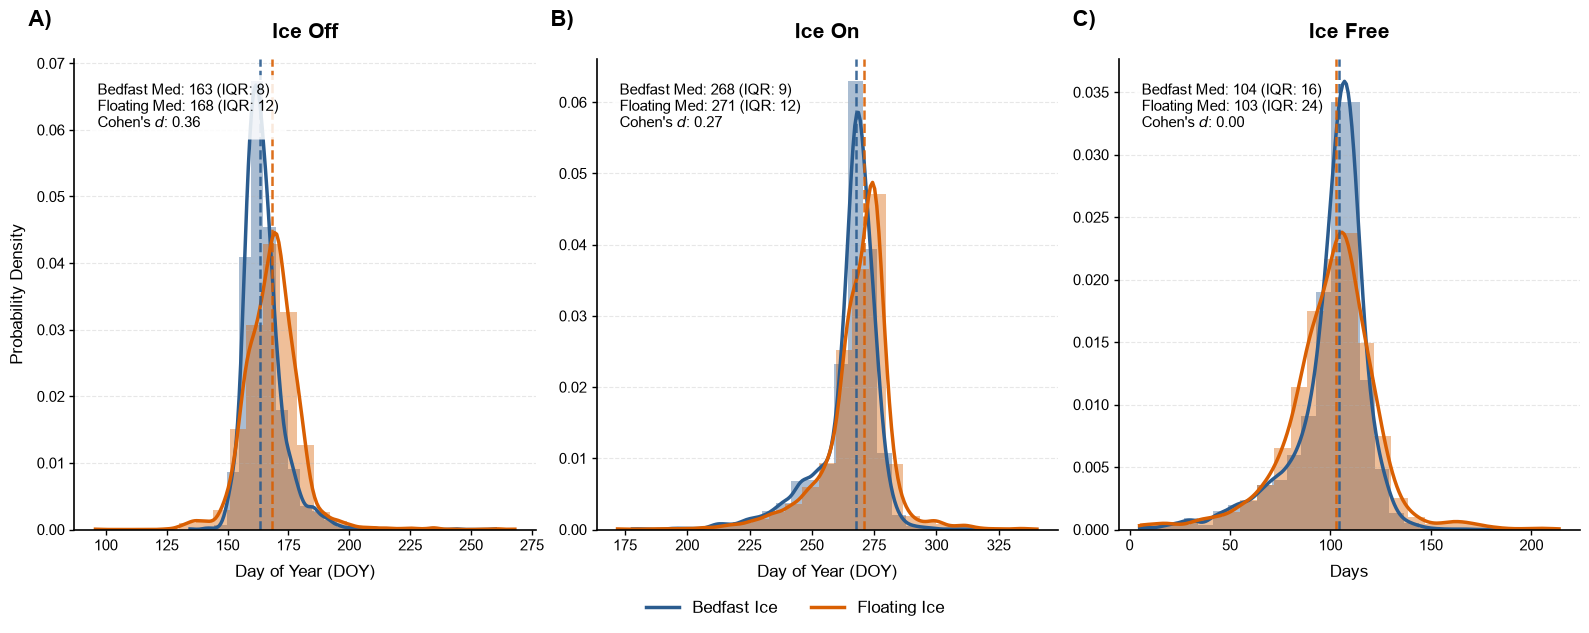

In [21]:
# --- Section 5: Multi-Panel Histogram Figure (Enhanced Readability) ---
# Set publication-quality figure styles globally with increased base font sizes
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0

plot_data = joined_data.dropna(subset=["Binary"])
bedfast_ice = plot_data[plot_data["Binary"] == 0]
floating_ice = plot_data[plot_data["Binary"] == 1]

# Increased figure height to 6 inches for better vertical separation
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False) 
metrics = ["ice_off_doy", "ice_on_doy", "ice_free_days"]
titles = ["Ice Off", "Ice On", "Ice Free"]
x_labels = ["Day of Year (DOY)", "Day of Year (DOY)", "Days"]
panel_labels = ["A)", "B)", "C)"]  

colors = {"bedfast": "#2b5c8f", "floating": "#d95f02"} 
bins_count = 25

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    b_data = bedfast_ice[metric].dropna().values
    f_data = floating_ice[metric].dropna().values
    
    # Plot normalized histograms
    ax.hist(b_data, bins=bins_count, density=True, alpha=0.4, color=colors["bedfast"], edgecolor="none")
    ax.hist(f_data, bins=bins_count, density=True, alpha=0.4, color=colors["floating"], edgecolor="none")
    
    # Smooth Kernel Density Estimation (KDE) Lines
    if len(b_data) > 1:
        kde_b = gaussian_kde(b_data)
        x_eval = np.linspace(b_data.min(), b_data.max(), 200)
        ax.plot(x_eval, kde_b(x_eval), color=colors["bedfast"], lw=2.5)
        
    if len(f_data) > 1:
        kde_f = gaussian_kde(f_data)
        x_eval = np.linspace(f_data.min(), f_data.max(), 200)
        ax.plot(x_eval, kde_f(x_eval), color=colors["floating"], lw=2.5)

    # Add Vertical Median Lines
    med_b = np.median(b_data)
    med_f = np.median(f_data)
    ax.axvline(med_b, color=colors["bedfast"], linestyle="--", lw=1.8, alpha=0.9)
    ax.axvline(med_f, color=colors["floating"], linestyle="--", lw=1.8, alpha=0.9)
    
    # Calculate Separability Statistics (Cohen's d)
    pool_sd = np.sqrt((np.var(b_data, ddof=1) + np.var(f_data, ddof=1)) / 2)
    cohens_d = abs(np.mean(b_data) - np.mean(f_data)) / pool_sd if pool_sd > 0 else 0
    
    # Calculate spread metrics
    iqr_b = np.percentile(b_data, 75) - np.percentile(b_data, 25)
    iqr_f = np.percentile(f_data, 75) - np.percentile(f_data, 25)
    
    stats_text = (
        f"Bedfast Med: {med_b:.0f} (IQR: {iqr_b:.0f})\n"
        f"Floating Med: {med_f:.0f} (IQR: {iqr_f:.0f})\n"
        f"Cohen's $d$: {cohens_d:.2f}"
    )
    
    # Display Inner Stats Text Box (Increased text size to 10.5)
    ax.text(
        0.05, 0.95, stats_text, 
        transform=ax.transAxes, 
        fontsize=10.5, 
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="none", alpha=0.85)
    )
    
    # Formatting text sizes for labels, titles, and ticks
    ax.set_title(titles[i], fontsize=15, fontweight="bold", pad=15)
    ax.set_xlabel(x_labels[i], fontsize=12, labelpad=8)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=11)
    
    # Panel Labels (Increased to 16)
    ax.text(
        -0.05, 1.06, 
        panel_labels[i], 
        transform=ax.transAxes, 
        fontsize=16, 
        fontweight="bold", 
        va="bottom", 
        ha="right"
    )

axes[0].set_ylabel("Probability Density", fontsize=12, labelpad=8)

# Unified Legend (Removed '(0)' and '(1)' references, increased text size to 12)
labels = ["Bedfast Ice", "Floating Ice"]
handles = [
    plt.Line2D([0], [0], color=colors["bedfast"], lw=2.5, linestyle="-"),
    plt.Line2D([0], [0], color=colors["floating"], lw=2.5, linestyle="-")
]
fig.legend(
    handles, 
    labels, 
    loc="lower center", 
    bbox_to_anchor=(0.5, -0.06), 
    ncol=2, 
    fontsize=12, 
    frameon=False
)

plt.tight_layout()
plt.savefig("lake_ice_separability_analysis.png", dpi=300, bbox_inches="tight")
plt.show()